# Static Networks - Generating MEIs

Now that we have a trained neural network $\hat{f}$ such that $\hat{f}(s) \approx \mathbf{r} = f(s)$, it is time to analyze the network to gain some insight into the modeled system.

In particular, we are going to consider generating the **Most Exciting Input** for each modeled neuron, and do so by incrementally modifying the input image by the gradient of the target neuron $r_i$ with respect to the image $I$, $\frac{\partial r_i}{\partial I}$, such that:

$$
I^{(k+1)} = I^{(k)} + \lambda \frac{\partial r_i}{\partial I} |_{I = I^{k}}
$$

Let's first attempt on doing this using the above definition directly.

In [73]:
import datajoint as dj
import torch
import numpy as np
import matplotlib.pyplot as plt

In [92]:
from staticnet_experiments import models, configs
from neuro_data.static_images import data_schemas as static

Let's take best model for Group ID 23.

In [90]:
static.StaticMultiDataset.Member & 'group_id = 23'

group_id index of group,animal_id id number,session session index for the mouse,scan_idx number of TIFF stack file,pipe_version,segmentation_method,spike_method spike inference method,preproc_id preprocessing ID,name string description to be used for training
23,20892,9,10,1,6,5,0,group023-20892-9-10-0


In [95]:
models.Model & 'group_id = 23'

group_id index of group,net_hash unique identifier for configuration,seed random seed,val_corr validation correlation (single trial),model stored model
23,09c01eed166986e26a07eb342da31f4a,1009,0.30488,=BLOB=
23,09c01eed166986e26a07eb342da31f4a,1215,0.311399,=BLOB=
23,09c01eed166986e26a07eb342da31f4a,2606,0.323661,=BLOB=
23,09c01eed166986e26a07eb342da31f4a,99999,0.308958,=BLOB=
23,0e26ab7ecd6b266be4ce503d7722132b,1009,0.273308,=BLOB=
23,0e26ab7ecd6b266be4ce503d7722132b,1215,0.275406,=BLOB=
23,0e26ab7ecd6b266be4ce503d7722132b,2606,0.304928,=BLOB=
23,0e26ab7ecd6b266be4ce503d7722132b,99999,0.275829,=BLOB=
23,1561ced693fe00dcca62a9761a4fccd2,1009,0.352418,=BLOB=
23,1561ced693fe00dcca62a9761a4fccd2,1215,0.357202,=BLOB=


You can see that we have 64 networks trained on this dataset. Let's take the network with best validation set correlation.

In [146]:
best = dj.U().aggr(models.Model() & 'group_id = 23', best_corr='max(val_corr)') * models.Model() & 'best_corr = val_corr'
best

group_id index of group,net_hash unique identifier for configuration,seed random seed,best_corr calculated attribute,val_corr validation correlation (single trial),model stored model
23,1561ced693fe00dcca62a9761a4fccd2,1215,0.357202,0.357202,=BLOB=


In [147]:
best_model_key = best.fetch1('KEY')
best_model_key

{'group_id': 23, 'net_hash': '1561ced693fe00dcca62a9761a4fccd2', 'seed': 1215}

In [148]:
models.Model & best_model_key

group_id index of group,net_hash unique identifier for configuration,seed random seed,val_corr validation correlation (single trial),model stored model
23,1561ced693fe00dcca62a9761a4fccd2,1215,0.357202,=BLOB=


Let's load that network

In [149]:
net = models.Model().load_network(best_model_key)

21-06-2019:08:54:00 INFO     configs.py           224:	 Ignoring input arguments: "schedule", "mod_hash", "train_hash", "train_type", "ro_hash", "net_hash", "max_epoch", "seed", "core_hash", "group_id", "shift_hash", "data_hash"when creating datasets
21-06-2019:08:54:00 INFO     configs.py           203:	 Loading None dataset with tier=train
21-06-2019:08:54:00 INFO     data_schemas.py      962:	 Fetching data for {'data_description': 'all-unknown L2/3 on stimulus.Frame. normalize=True on all (except "")', 'mod_hash': 'a757e992ae449e3057ff1d512a51bd1e', 'train_hash': '2c25349fa0a81afbe907882e7b50a4da', 'stats_source': 'all', 'normalize': 1, 'ro_hash': 'a206f6da6a16ea14081062a1e2436b48', 'group_id': 23, 'layer': 'L2/3', 'seed': 1215, 'brain_areas': 'all-unknown', 'core_hash': '28bc2fa358337c5012278f899b5b6947', 'normalize_per_image': 0, 'net_hash': '1561ced693fe00dcca62a9761a4fccd2', 'shift_hash': '05c69a4aeaeea5e48fa8fc5e70181d67', 'data_hash': '2f2bdcdc357504275c829734749a4b38'}
21-06

/usr/local/lib/python3.5/dist-packages/h5py/_hl/dataset.py:313: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  "Use dataset[()] instead.", H5pyDeprecationWarning)
/usr/local/lib/python3.5/dist-packages/h5py/_hl/dataset.py:313: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  "Use dataset[()] instead.", H5pyDeprecationWarning)


21-06-2019:08:54:01 INFO     shifters.py           56:	 Ignoring input {'shift_hash': '05c69a4aeaeea5e48fa8fc5e70181d67'} when creating MLPShifter
21-06-2019:08:54:01 INFO     shifters.py           28:	 Ignoring input {} when creating MLP
21-06-2019:08:54:01 INFO     modulators.py         47:	 Ignoring input {'mod_hash': 'a757e992ae449e3057ff1d512a51bd1e'} when creating MLPModulator
21-06-2019:08:54:01 INFO     modulators.py         18:	 Ignoring input {} when creating MLP


In [150]:
# put it under evaluation model
net.eval()

CorePlusReadout2d(
  (core): GaussianLaplaceCore(
    (_input_weights_regularizer): LaplaceL2(
      (laplace): Laplace()
    )
    (features): Sequential(
      (layer0): Sequential(
        (conv): Conv2d(1, 32, kernel_size=(15, 15), stride=(1, 1), bias=False)
        (norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (nonlin): ELU(alpha=1.0, inplace)
      )
      (layer1): Sequential(
        (conv): Conv2d(32, 32, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False)
        (norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (nonlin): ELU(alpha=1.0, inplace)
      )
      (layer2): Sequential(
        (conv): Conv2d(64, 32, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False)
        (norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (nonlin): ELU(alpha=1.0, inplace)
      )
    )
  ) [GaussianLaplaceCore regularizers: gamma_hidd

Now let's try to generate an image that will maximally activate a target neuron, say the neuron at index 3188.

Let's start with a white noise image.

In [209]:
image = torch.randn(1, 1, 36, 64, requires_grad=True)  # make it backpropagatable

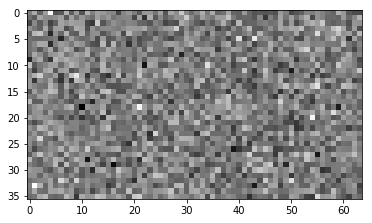

In [211]:
plt.imshow(image.data.numpy().squeeze(), cmap='gray')

In [212]:
image.grad # no gradient attached yet

In [213]:
unit = 3188

activation = net(image, readout_key='group023-20892-9-10-0')[0, unit]  # activation of unit 267
activation

tensor(0.6320)

In [214]:
# compute gradient of this with respect to the image
activation.backward()

In [215]:
image.grad  # this is now computed

tensor(1.00000e-02 *
       [[[[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]]])

In [216]:
# modify the image by the gradient
image.data = image.data + image.grad
image.grad.zero_()

tensor([[[[ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
          ...,
          [ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  ...,  0.,  0.,  0.]]]])

Check activation again

In [217]:
activation = net(image, readout_key='group023-20892-9-10-0')[0, unit]  # activation of unit 267
activation

tensor(0.7543)

Let's do this a bit more systematically.

In [218]:
from torch.optim import SGD
from tqdm import tqdm

image = torch.randn(1, 1, 36, 64, requires_grad=True)  # make it backpropagatable
optimizer = SGD([image], lr=1)

activations = []
images = []
for i in tqdm(range(100)):
    optimizer.zero_grad() # reset gradient
    images.append(image.data.numpy().copy())
    
    
    activation = net(image, readout_key='group023-20892-9-10-0')[0, unit]  # activation of unit 267
    activations.append(activation)
    
    # note that optimizer tries to MINIMIZE the score, thus you need to give negative activation
    loss = -activation
    loss.backward() # compute gradient
    optimizer.step() # perform single step of gradient ascent

images = np.stack(images)

100%|██████████| 100/100 [00:30<00:00,  3.27it/s]


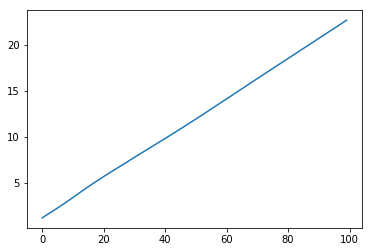

In [219]:
plt.plot(activations)

/usr/local/lib/python3.5/dist-packages/matplotlib/tight_layout.py:211: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations
  warnings.warn('Tight layout not applied. '


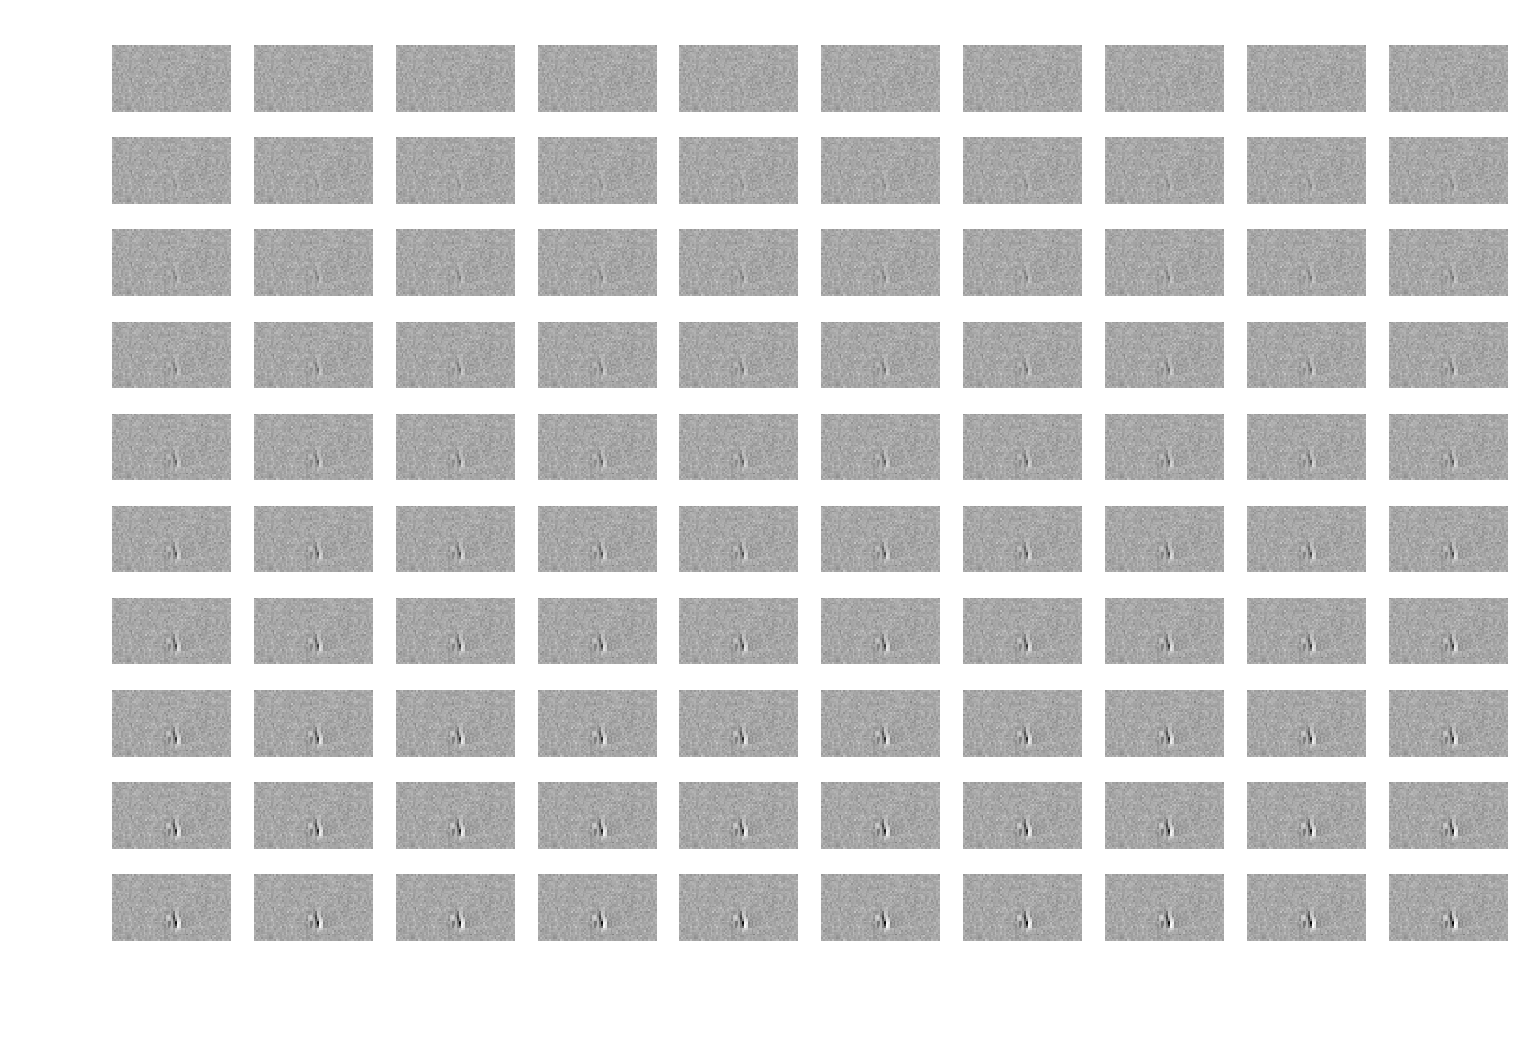

In [220]:
fig, axs = plt.subplots(10, 10, dpi=300)
vmin, vmax = images.min(), images.max()
for ax, img in zip(axs.ravel(), images):
    ax.imshow(img.squeeze(), vmin=vmin, vmax=vmax, cmap='gray')
    ax.axis('off')
    
fig.tight_layout()

## `static_analyses` package

All code pertaining to MEI generation as was used for Walker et al 2018 can be found inside `staticnet_analyses.multi_mei` subpackage.

In [221]:
from staticnet_analyses import multi_mei

/src/static-networks/staticnet_analyses/multi_mei.py:1757: UserWarning: Use of this table is deprecated. It is kept only for record keeping purpose
  warnings.warn('Use of this table is deprecated. It is kept only for record keeping purpose')


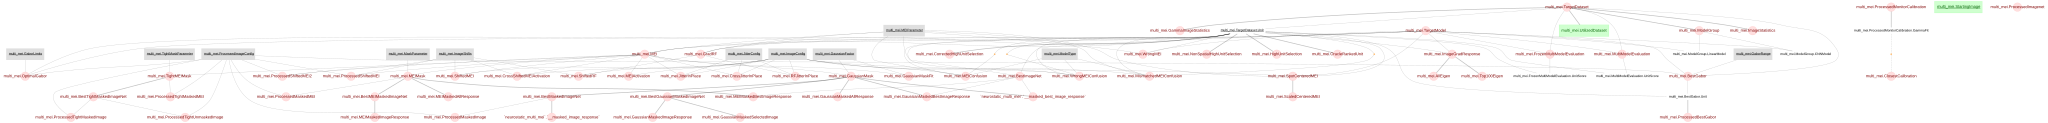

In [222]:
dj.ERD(multi_mei)

Let's focus on some key tables.

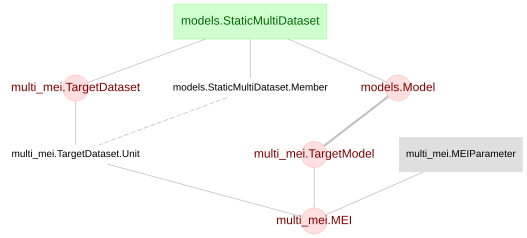

In [223]:
dj.ERD(multi_mei.TargetModel) + multi_mei.MEI + multi_mei.MEIParameter + models.Model + multi_mei.TargetDataset.Unit \
+ multi_mei.TargetDataset + multi_mei.StaticMultiDataset

`multi_mei.MEI` generates MEI for each neuron of the model for each possible configuration as specified in `multi_mei.MEIParameter`.

In [188]:
multi_mei.MEIParameter()

mei_param_id id,iter_n number of iterations to run,start_sigma starting sigma value,end_sigma ending sigma value,start_step_size starting step size,end_step_size ending step size,precond strength of gradient preconditioning filter falloff,step_gain scaling of gradient steps,jitter size of translational jittering,blur whether to apply bluring or not,"norm norm adjustment after step, negative to turn off","train_norm norm adjustment during step, negative to turn off"
150966b4691c643986d738a5f6656594,1000,1.5,0.01,3.0,0.125,0.1,0.1,0,1,-1.0,-1.0
9a0fc64f1c2627e7df33560eee3905ef,1000,1.5,0.01,3.0,0.125,0.1,0.1,0,0,-1.0,11.0


Let's take a look at the MEI for our model `best_model_key` for `neuron_id = 3188`

In [225]:
img = (multi_mei.MEI() & best_model_key & 'neuron_id = 3188').fetch1('mei')

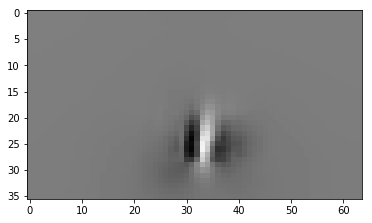

In [226]:
plt.imshow(img, vmin=0, vmax=255, cmap='gray')

Methods for MEI generation employed inside `multi_mei` tends to yield much more robust/stable MEIs then the vanila implementation.

## Summary

In this notebook, we explored generating MEIs for a trained network. While simple in concept, implementing an MEI generation that is robust can be rather tricky, where a robust method typically would employ some form of regularizations during the generation process.